# Video Segmentation Technique for Tracking Hand Movement

My idea:
- extract frames from a video 
- use image segmentation technique to only get blue gloves from a frame
- track speed of movement and so on from the segmented frame

Glove color based segmentation:
1. Source: https://medium.com/@karen.mossoyan/hand-segmentation-with-python-and-tensorflow-70c38db855b5
- teaches the basic of selecting the right model to train the segmentation 
- but to train the model I need to have ground truth mask
- NOTE: Interesting thing to learn if I have time 📕
2. Source: https://realpython.com/python-opencv-color-spaces/
- focus on image segmentation from color space instead of using deep learning model 
- this is what I will be following hehe

## Extract frames

In [ ]:
# first lets extract frames out from a video
# video dir -- /tmp/Y54I_trimmed_1min.mp4

# Modified from Source - https://stackoverflow.com/a/33399711
# Posted by fireant, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-07, License - CC BY-SA 4.0

import cv2
vidcap = cv2.VideoCapture('/tmp/Y54I_trimmed_1min.mp4')
success,image = vidcap.read()
count = 0
while success:
  cv2.imwrite("frame_result/frame%d.jpg" % count, image)     # save frame as JPEG file
  success,image = vidcap.read()
  count += 1
print(f"done: got {count} frames")
# got 1800 frames out of 60 second videos

done: got 1800 frames


## Glove color based segmentation

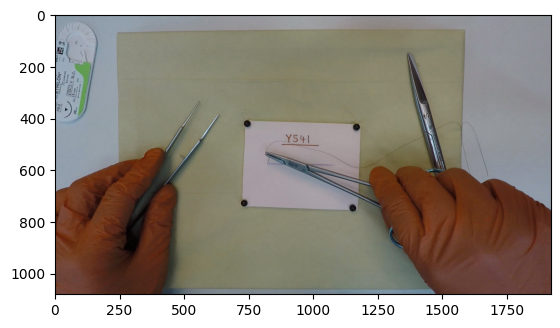

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# first lets read a frame to see how it looks like
frame0 = cv2.imread("./frame_result/frame0.jpg")
plt.imshow(frame0)
plt.show()

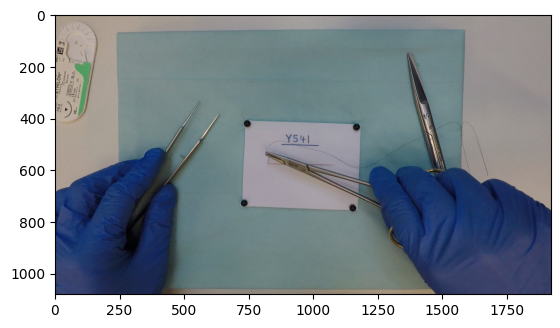

In [2]:
# cv2 read image in BGR format -- change to RGB with the folling
frame0 = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)
plt.imshow(frame0)
plt.show()

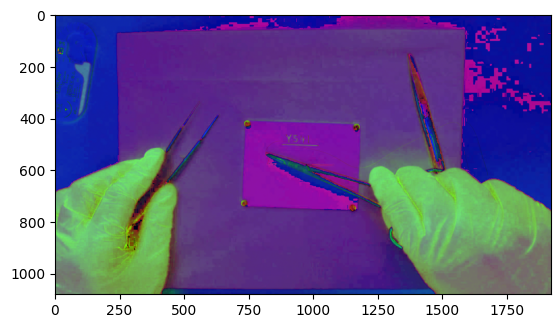

In [3]:
hsv_frame0 = cv2.cvtColor(frame0, cv2.COLOR_RGB2HSV)
plt.imshow(hsv_frame0)
plt.show()

In [ ]:
# lets observe RGB color space with frame0 : https://realpython.com/python-opencv-color-spaces/
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib import colors

def plot_color_space(frame: list[list[int]]) -> None:
    r, g, b = cv2.split(frame) # split image into its component channels
    fig = plt.figure()
    axis = fig.add_subplot(1, 1, 1, projection="3d")

    pixel_colors = frame.reshape((np.shape(frame)[0]*np.shape(frame)[1], 3))
    norm = colors.Normalize(vmin=-1.,vmax=1.)
    norm.autoscale(pixel_colors)
    pixel_colors = norm(pixel_colors).tolist()

    axis.scatter(r.flatten(), g.flatten(), b.flatten(), facecolors=pixel_colors, marker=".")
    axis.set_xlabel("Red")
    axis.set_ylabel("Green")
    axis.set_zlabel("Blue")
    plt.show()

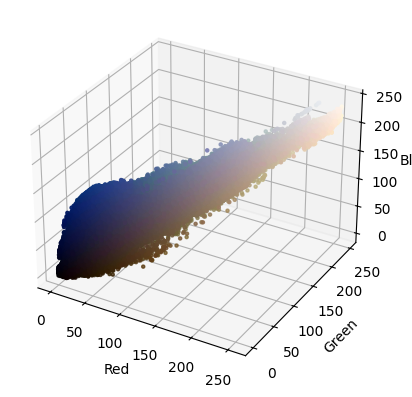

In [11]:
plot_color_space(frame0)

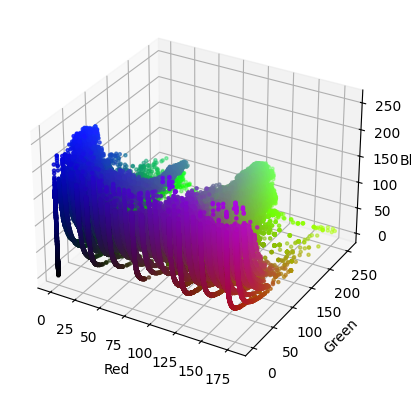

In [ ]:
# the green means the blue gloves -- now we can see that it is more seggreagted
hsv_frame0 = cv2.cvtColor(frame0, cv2.COLOR_RGB2HSV)
plot_color_space(hsv_frame0)

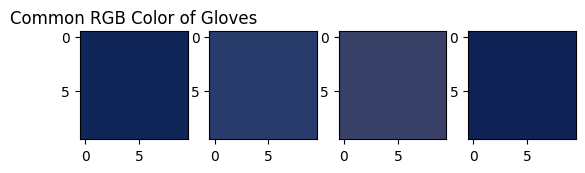

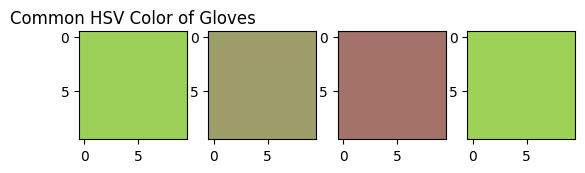

In [13]:
# different shades of blue
# the most common to see from https://imagecolorpicker.com/#google_vignette

from matplotlib.colors import rgb_to_hsv

blue1 = (16, 38, 88)
blue2 = (40, 59, 106)
blue3 = (58, 65, 105)
blue4 = (15, 34, 86)

blue_sqaure1 = np.full((10, 10, 3), blue1, dtype=np.uint8) / 255.0
blue_sqaure2 = np.full((10, 10, 3), blue2, dtype=np.uint8) / 255.0
blue_sqaure3 = np.full((10, 10, 3), blue3, dtype=np.uint8) / 255.0
blue_sqaure4 = np.full((10, 10, 3), blue4, dtype=np.uint8) / 255.0

# 1 row, 4 column
plt.subplot(1, 4, 1)
plt.imshow(blue_sqaure1)
plt.title("Common RGB Color of Gloves")
plt.subplot(1, 4, 2)
plt.imshow(blue_sqaure2)
plt.subplot(1, 4, 3)
plt.imshow(blue_sqaure3)
plt.subplot(1, 4, 4)
plt.imshow(blue_sqaure4)
plt.show()

# 1 row, 4 column
plt.subplot(1, 4, 1)
plt.imshow(rgb_to_hsv(blue_sqaure1))
plt.title("Common HSV Color of Gloves")
plt.subplot(1, 4, 2)
plt.imshow(rgb_to_hsv(blue_sqaure2))
plt.subplot(1, 4, 3)
plt.imshow(rgb_to_hsv(blue_sqaure3))
plt.subplot(1, 4, 4)
plt.imshow(rgb_to_hsv(blue_sqaure4))
plt.show()

In [29]:
from colorsys import rgb_to_hsv

def rgb_to_hsv_cv(r, g, b):
    h, s, v = rgb_to_hsv(r/255, g/255, b/255)
    return (h*180, s*255, v*255)

print(rgb_to_hsv_cv(58, 65, 105))

(115.53191489361704, 114.14285714285714, 105.0)


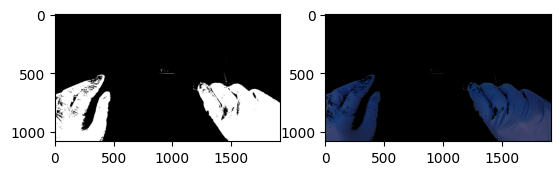

In [4]:
# mask the color on the image

lower_blue = np.array([100, 80,  60])   # Hue, Saturation, Value
upper_blue = np.array([130, 220, 120])

mask   = cv2.inRange(hsv_frame0, lower_blue, upper_blue)
result = cv2.bitwise_and(frame0, frame0, mask=mask)
plt.subplot(1, 2, 1)
plt.imshow(mask, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(result)
plt.show()

In [9]:
print(mask)
print(len(mask))
print(len(mask[0]))

[[  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 ...
 [  0 255 255 ... 255 255 255]
 [  0   0 255 ... 255 255 255]
 [  0   0 255 ... 255 255 255]]
1080
1920


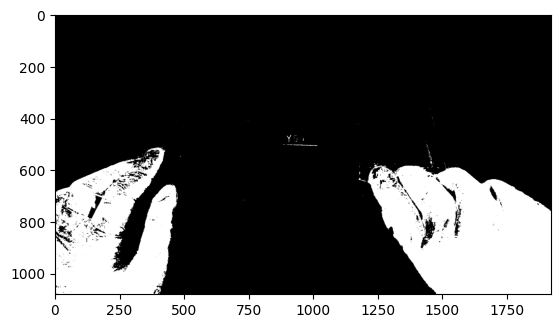

In [8]:
plt.imshow(mask, cmap = 'gray')
plt.show()

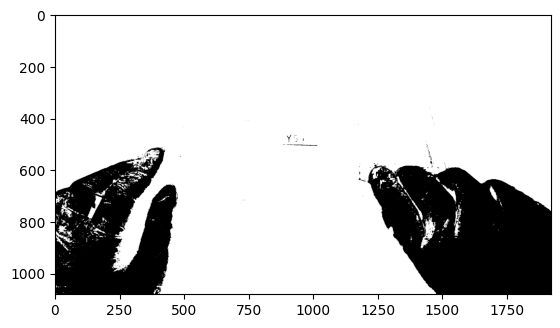

In [ ]:
# quick way to reverse black and white
for i in range(0, 1080):
    for j in range(0, 1920):
        if mask[i][j] == 0:
            mask[i][j] = 255
        else:
            mask[i][j] = 0
plt.imshow(mask, cmap = 'gray')
plt.show()

### Combine everything together for writing a funciton

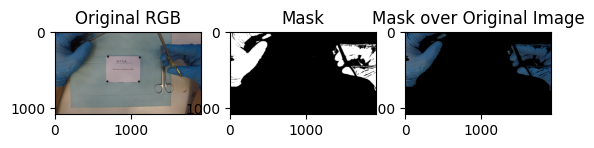

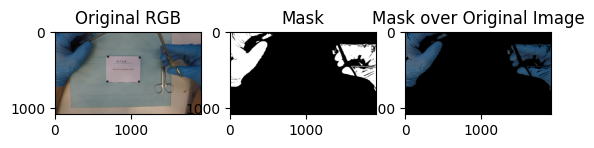

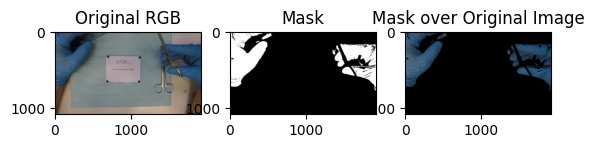

In [24]:
# test on combining things together for writing function
import cv2
import matplotlib.pyplot as plt
import numpy as np

# data
vidcap = cv2.VideoCapture('../data/videos/H13A.mp4')
# needs a better definition of color -- can do this mathematically
# lower_blue = np.array([100, 80,  60])   # HSV
# upper_blue = np.array([130, 220, 120])
lower_blue = np.array([100, 80,  60])
upper_blue = np.array([110, 200, 150])

success,image = vidcap.read()
count = 0
while success:
  if count < 3:
    success,image_bgr = vidcap.read()
    # convert from BGR to HSV
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    # select only the color defined
    mask   = cv2.inRange(image_hsv, lower_blue, upper_blue)
    result = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)
    # save mask to a folder -- or extract centroid and stuff here
    cv2.imwrite(f"../result/test/frame_{count}.png", mask)
    # find contour and centroid from mask right away
    # see the results
    plt.subplot(1, 3, 1)
    plt.title("Original RGB")
    plt.imshow(image_rgb)
    plt.subplot(1, 3, 2)
    plt.title("Mask")
    plt.imshow(mask, cmap="gray")
    plt.subplot(1, 3, 3)
    plt.title("Mask over Original Image")
    plt.imshow(result)
    plt.show()
    count += 1
  elif count == 3:
      # hard stop just to test 2 frames
      success = False

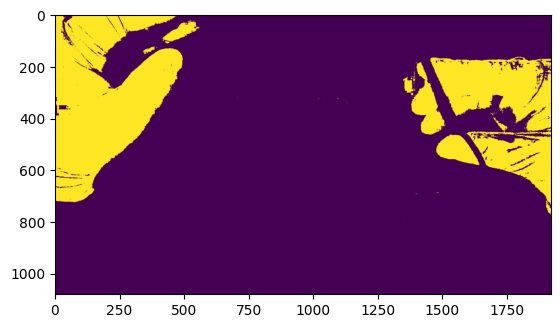

In [25]:
plt.imshow(mask)
plt.show()

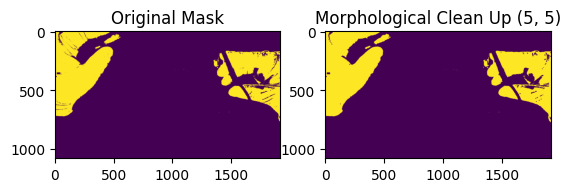

In [ ]:
import cv2
import numpy as np

# bigger kernel stronger filling
size = (7,7) # lets stick with 7s for now
kernel = np.ones(size, np.uint8)

closed_mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_CLOSE,
    kernel
)

# plot it out to see the result
plt.subplot(1,2,1)
plt.imshow(mask)
plt.title("Original Mask")

plt.subplot(1,2,2)
plt.imshow(closed_mask)
plt.title(f"Morphological Clean Up {str(size)}")

plt.savefig(f"../result/test/plot_{size}.png")
plt.show()

In [35]:
def plot_compare(left_item, right_item):
    plt.subplot(1,2,1)
    plt.imshow(left_item)
    plt.title("Original Mask")

    plt.subplot(1,2,2)
    plt.imshow(right_item)
    plt.title(f"After clean up")

    plt.show()

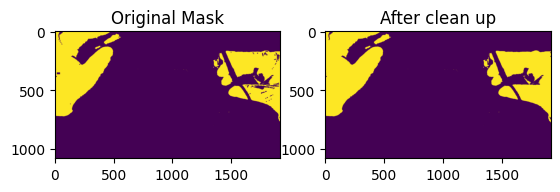

In [ ]:
# NOTE: I need to understand how this works

def fill_holes(mask):
    # make sure binary
    mask = (mask > 0).astype(np.uint8) * 255
    h, w = mask.shape
    # add black border
    padded = np.zeros((h+2, w+2), np.uint8)
    padded[1:h+1,1:w+1] = mask
    flood = padded.copy()
    flood_mask = np.zeros((h+4,w+4), np.uint8)
    cv2.floodFill(
        flood,
        flood_mask,
        (0,0),
        255
    )
    # invert flood filled image
    flood_inv = cv2.bitwise_not(flood)
    # combine
    filled = padded | flood_inv
    # remove border
    filled = filled[1:h+1,1:w+1]
    return filled


filled_mask = fill_holes(closed_mask)
plot_compare(closed_mask, filled_mask)

# print(type(filled_mask))
# np.savetxt("../result/test/filled_mask.txt", filled_mask, fmt="%d")

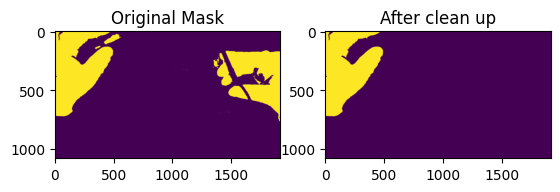

In [ ]:
# remove small noise region
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    filled_mask,
    connectivity=8
)
largest_component = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
clean_mask = np.zeros_like(filled_mask)
clean_mask[
    labels == largest_component
] = 255

plot_compare(filled_mask, clean_mask)

## Points for Tracking Movement

In [ ]:
print(mask)
print(type(mask))
print(mask.shape)

[[255 255 255 ...   0   0   0]
 [255 255 255 ...   0   0   0]
 [255 255 255 ...   0   0   0]
 ...
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]
<class 'numpy.ndarray'>
(1080, 1920)


In [ ]:
# write a function to fill in the gap of 0 in 255 bounday


# write a function to change from 255 to 0 when there are low amount to clean up

In [50]:
import numpy as np
np.savetxt('../result/test/mask.txt', mask, fmt='%d')

In [9]:
print("White pixels:", np.count_nonzero(mask))

White pixels: 292389


In [35]:
# from above we have image_rgb, image_hsv, mask, result

contours, hierarchy = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,      # Only outer contours
    cv2.CHAIN_APPROX_NONE   # Keep every contour point
)

print(type(contours))
print(len(contours))
print(contours[0][0][0][0])
print(contours[0][0][0][1])
# my guess is : it is a tuple of all coordinate of contours

<class 'tuple'>
203
1348
801


In [37]:
x = []
y = []
for i in range(0, 203):
    x.append(contours[i][0][0][0])
    y.append(contours[i][0][0][1])

print(x)
print(y)

[np.int32(1348), np.int32(1907), np.int32(1395), np.int32(1472), np.int32(1477), np.int32(1714), np.int32(1814), np.int32(1696), np.int32(1711), np.int32(1903), np.int32(1860), np.int32(1910), np.int32(1904), np.int32(1909), np.int32(1728), np.int32(1827), np.int32(1760), np.int32(1529), np.int32(1732), np.int32(1676), np.int32(1525), np.int32(1784), np.int32(1713), np.int32(1776), np.int32(1800), np.int32(1849), np.int32(1845), np.int32(1830), np.int32(1916), np.int32(1888), np.int32(1769), np.int32(1764), np.int32(1739), np.int32(1774), np.int32(1819), np.int32(1765), np.int32(1797), np.int32(1815), np.int32(1915), np.int32(1495), np.int32(1808), np.int32(1775), np.int32(1814), np.int32(1497), np.int32(1780), np.int32(1748), np.int32(1777), np.int32(1499), np.int32(1772), np.int32(1774), np.int32(1816), np.int32(1821), np.int32(1816), np.int32(1819), np.int32(1777), np.int32(1781), np.int32(1787), np.int32(1790), np.int32(1776), np.int32(1793), np.int32(1818), np.int32(1777), np.int3

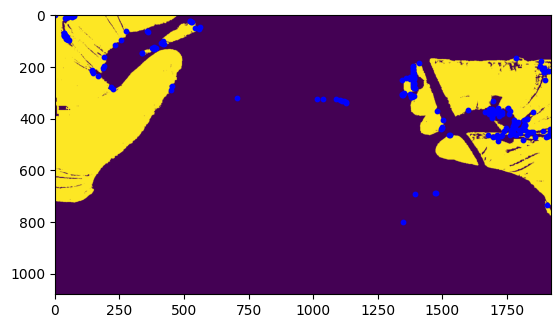

In [46]:
# show original mask on the background
plt.imshow(mask)
# tracked points
plt.scatter(x, y, color='blue', s=10)

plt.xlim(0, 1920)
plt.ylim(1080, 0)
plt.show()

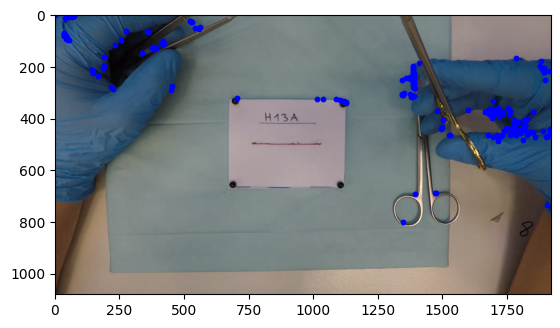

In [39]:
# show original image on the background
plt.imshow(image_rgb)
# tracked points
plt.scatter(x, y, color='blue', s=10)

plt.xlim(0, 1920)
plt.ylim(1080, 0)
plt.show()

NOTE: Contour points quality highly depends on the segment, lets try to the centroid method first
- what is a function moment
- what does it return 

In [41]:
M = cv2.moments(mask)
print(M)

if M["m00"] != 0:
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])

print("Centroid:", cx, cy)

{'m00': 96480780.0, 'm10': 79386402885.0, 'm01': 33031789905.0, 'm20': 120432071690145.0, 'm11': 29490959876730.0, 'm02': 14189604732525.0, 'm30': 2.0304258750190048e+17, 'm21': 4.658434940699604e+16, 'm12': 1.2738816127859914e+16, 'm03': 6849593454144585.0, 'mu20': 55111279683493.14, 'mu11': 2311712555025.035, 'mu02': 2880625427755.076, 'mu30': 1.3255134825911968e+16, 'mu21': 1548188024513138.0, 'mu12': -519593318579137.75, 'mu03': 19088246693190.0, 'nu20': 0.005920506792615655, 'nu11': 0.00024834316973227494, 'nu02': 0.0003094604681646238, 'nu30': 0.00014497133388737088, 'nu21': 1.693252358198336e-05, 'nu12': -5.682789157763299e-06, 'nu03': 2.0876804506532518e-07}
Centroid: 822 342


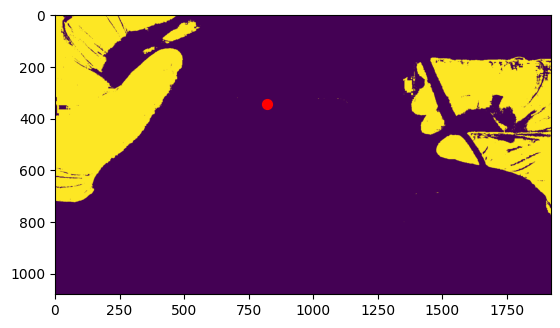

In [44]:
# show original mask on the background
plt.imshow(mask)
# tracked points
plt.scatter([822], [342], color='red', s=50)
plt.show()

[(1550, 523), (1865, 458), (1794, 555), (1364, 275), (1437, 356), (1712, 280), (485, 68), (181, 318)]
Left: (181, 318)
Right: (485, 68)


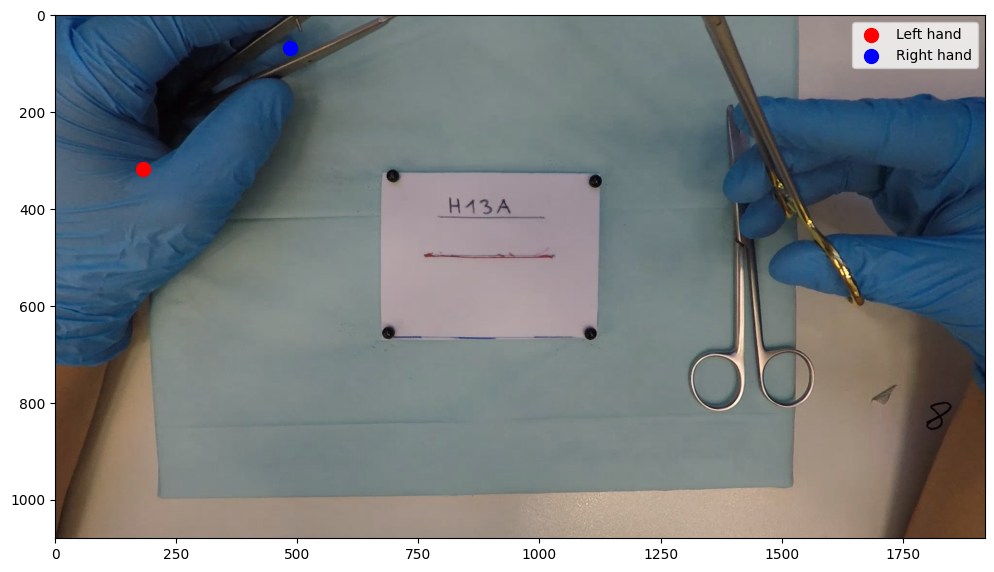

In [45]:
contours, hierarchy = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

centroids = []

for contour in contours:

    # remove small noise blobs
    if cv2.contourArea(contour) < 500:
        continue

    M = cv2.moments(contour)

    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        centroids.append((cx, cy))


print(centroids)

centroids = sorted(centroids, key=lambda x: x[0])

left_hand = centroids[0]
right_hand = centroids[1]

print("Left:", left_hand)
print("Right:", right_hand)

plt.figure(figsize=(12,8))

plt.imshow(image_rgb)

# left hand centroid
plt.scatter(
    left_hand[0],
    left_hand[1],
    color="red",
    s=100,
    label="Left hand"
)

# right hand centroid
plt.scatter(
    right_hand[0],
    right_hand[1],
    color="blue",
    s=100,
    label="Right hand"
)

plt.legend()
plt.show()